In [1]:
import torch
import numpy as np

import os

from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
output_path = '/data/scratch/hhy696/clipped_database/encoded/'

In [3]:
processed_files = os.listdir(output_path)

In [4]:
pooled_features = []
pooled_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name)
    data = data.mean(0)
    pooled_features.append(data.detach().numpy())


/tmp/5455082.1.all.q/ipykernel_90266/614715874.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(output_path+file_name)


In [5]:
pooled_array = np.array(pooled_features)

In [6]:
pca = PCA(n_components=8)
pca_features = pca.fit_transform(pooled_array)

In [10]:
classes = []
for name in pooled_names:
    classes.append(name.split('_')[1])
    
batches = []
for name in pooled_names:
    batches.append(name.split('_')[0])
    


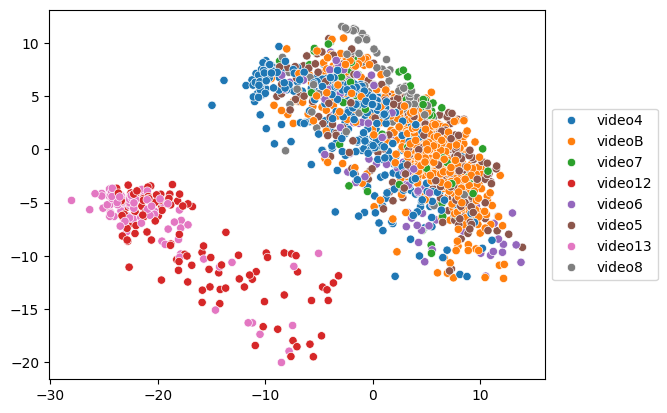

In [16]:

ax = sns.scatterplot(x = pca_features[:,0],y = pca_features[:,1], hue = batches)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

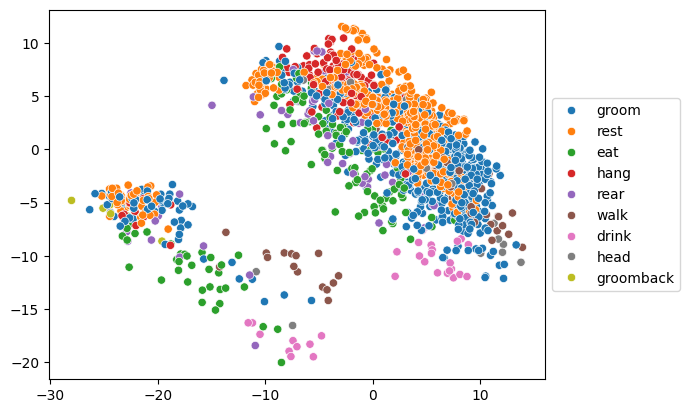

In [17]:
ax = sns.scatterplot(x = pca_features[:,0],y = pca_features[:,1], hue = classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

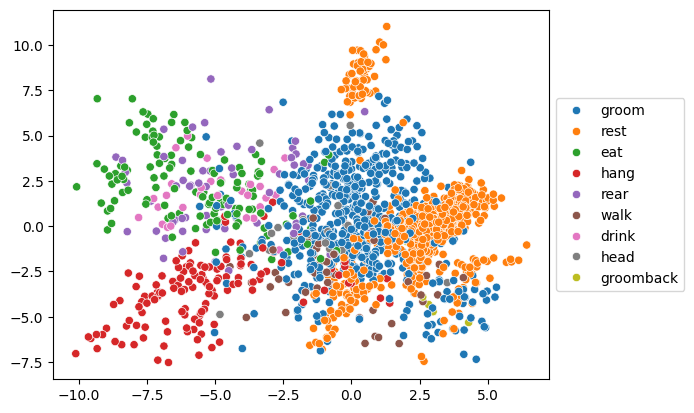

In [18]:
ax = sns.scatterplot(x = pca_features[:,2],y = pca_features[:,3], hue = classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


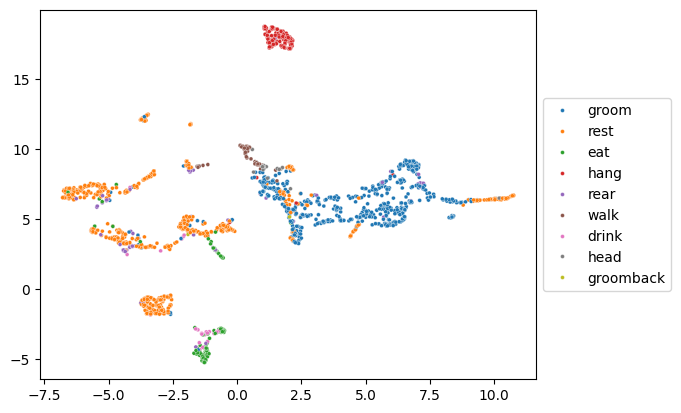

In [15]:
import umap
from sklearn.preprocessing import StandardScaler

reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(pca_features[:,3:])
embedding = reducer.fit_transform(scaled_features)
embedding.shape

ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], hue = classes, s=8)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

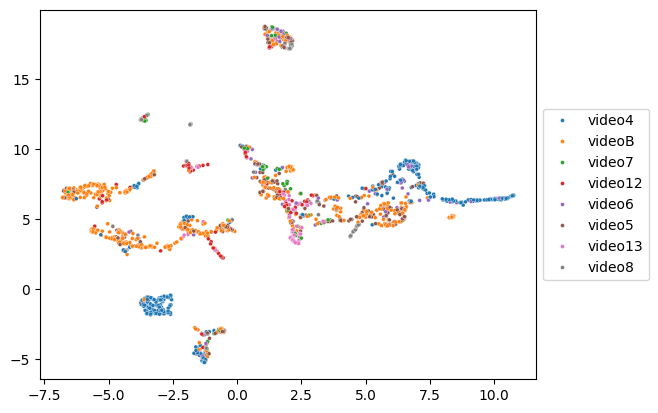

In [19]:
ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], hue = batches, s=8)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

In [20]:
fft_features = []
fft_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name, weights_only=True)
    if data.shape[0] == 30:
        fft_names.append(file_name)
        data = pca.transform(data.detach().numpy())
        freqs = np.abs(np.fft.rfft(data, axis=0))
        freqs = freqs.flatten()
        fft_features.append(freqs)


In [21]:
np.array(fft_features).shape

(1625, 128)

In [29]:
fft_features = np.array(fft_features)

In [30]:
classes = []
for name in fft_names:
    classes.append(name.split('_')[1])

In [37]:
pca2 = PCA(n_components=10)
pca_features = pca2.fit_transform(fft_features)

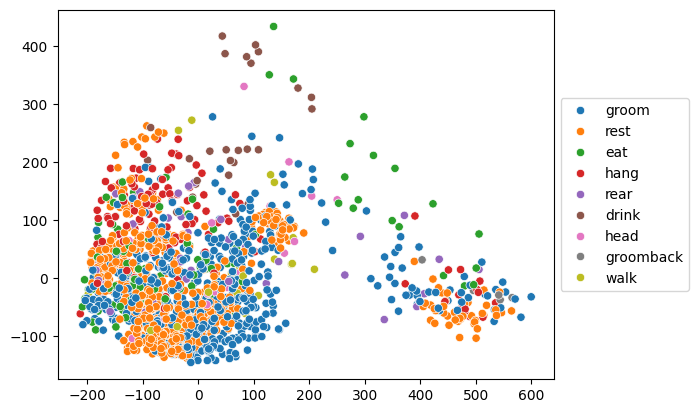

In [38]:
ax = sns.scatterplot(x = pca_features[:,0],y = pca_features[:,1], hue = classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


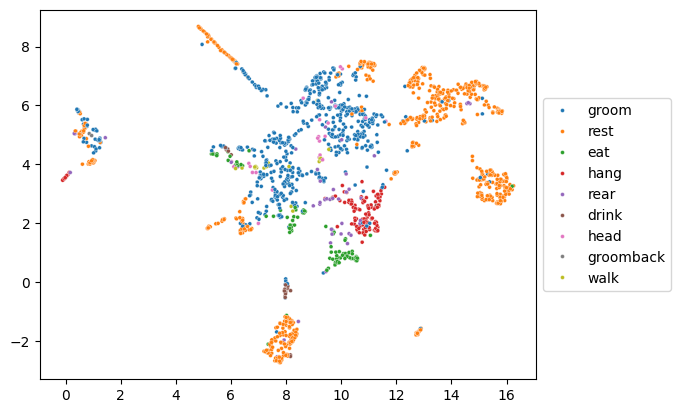

In [39]:
reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(pca_features)
embedding = reducer.fit_transform(scaled_features)
embedding.shape

ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], hue = classes, s=8)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

In [40]:
pca = PCA(n_components=8)
pca_features = pca.fit_transform(pooled_array)

In [41]:
pca_features = []
pca_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name, weights_only=True)
    if data.shape[0] == 30:
        pca_names.append(file_name)
        data = pca.transform(data.detach().numpy())
        pca_features.append(data)

In [42]:
len(pca_names)

1625

In [43]:
pca_features = np.array(pca_features)

In [44]:
from tslearn.utils import to_time_series_dataset


/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [45]:
formatted_dataset = to_time_series_dataset(pca_features)
formatted_dataset.shape

(1625, 30, 8)

In [46]:
from tslearn.clustering import TimeSeriesKMeans

km = TimeSeriesKMeans(n_clusters=8, metric="dtw")

km.fit(formatted_dataset[:,:,2:])

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The TimeSeriesKMeans or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


TimeSeriesKMeans(metric='dtw', n_clusters=8)

In [47]:
out = km.transform(formatted_dataset[:,:,2:])

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The TimeSeriesKMeans or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [48]:
out2 = np.concatenate((out, formatted_dataset[:,:,2:].mean(1)), axis=1)

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


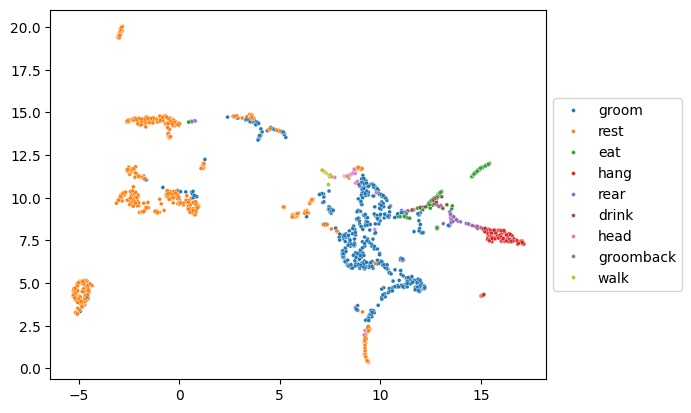

In [50]:
reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(out2)
embedding = reducer.fit_transform(scaled_features)
embedding.shape

ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

In [60]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))


In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    out2, classes, test_size=0.33, random_state=42)

In [62]:
clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])

In [69]:
from sklearn.metrics import confusion_matrix
y_pred = clf.predict(X_test)
cm =confusion_matrix(y_test, y_pred)

In [80]:
bm = cm/(cm.mean(1)+1)
bm

array([[1.8       , 0.57446809, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [1.2       , 6.5106383 , 0.        , 0.        , 0.16666667,
        0.        , 0.33333333, 0.        , 0.        ],
       [0.6       , 0.        , 7.93596059, 0.        , 0.        ,
        0.5625    , 0.33333333, 0.43231441, 0.6       ],
       [0.        , 0.        , 0.13300493, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.08866995, 0.        , 7.16666667,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        2.8125    , 0.        , 0.07860262, 0.        ],
       [0.        , 0.19148936, 0.1773399 , 0.        , 0.        ,
        0.        , 4.33333333, 0.        , 0.        ],
       [0.        , 0.        , 0.26600985, 0.        , 0.        ,
        0.        , 0.        , 8.41048035, 0.        ],


In [83]:
X_train.shape

(1088, 14)

<Axes: >

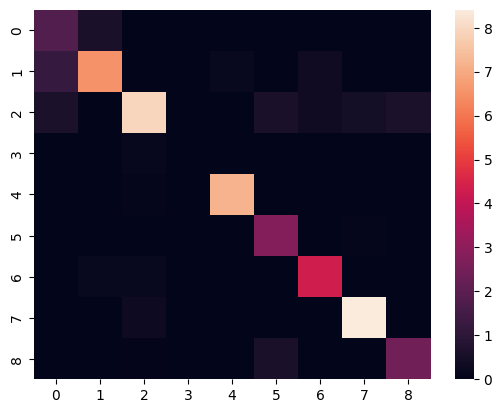

In [81]:
sns.heatmap(bm)

In [85]:
labels = km.predict(formatted_dataset[:,:,2:])

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The TimeSeriesKMeans or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [86]:
labels

array([7, 1, 5, ..., 2, 6, 5])

<Axes: >

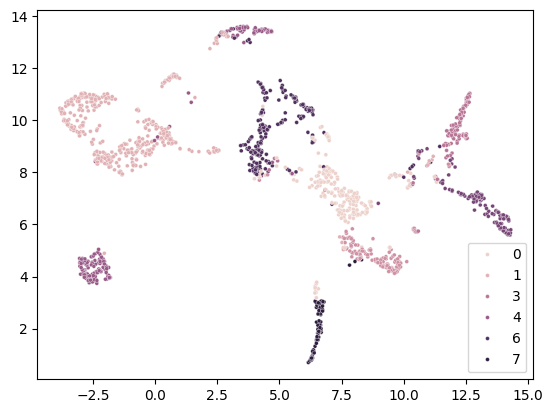

In [87]:
sns.scatterplot(x = embedding[:,0],y = embedding[:,1], hue=labels, s=8)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    formatted_dataset, classes, test_size=0.33, random_state=42)

In [88]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

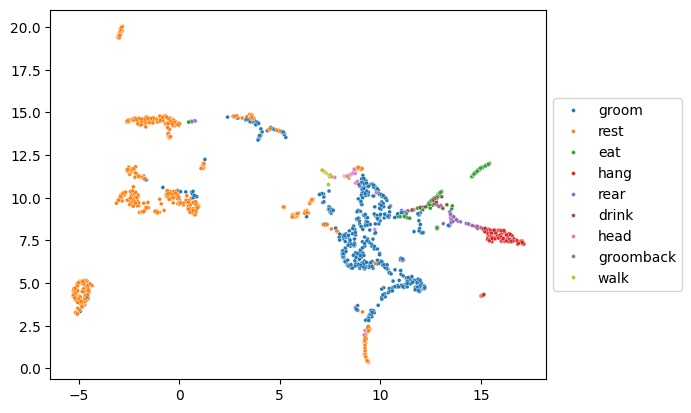

In [99]:
ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

In [131]:
from sklearn import preprocessing

labels = ['groom', 'rest', 'eat', 'hang', 'rear','drink','head','groomback','walk']
le = preprocessing.LabelEncoder()
y_train2 = torch.Tensor(le.fit_transform(y_train)).to(torch.long)
X_train2 = torch.from_numpy(X_train).to(torch.float32)

y_test2 = torch.Tensor(le.fit_transform(y_test)).to(torch.long)
X_test2 = torch.from_numpy(X_test).to(torch.float32)



In [136]:
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(RNNModel, self).__init__()
        
        # Number of hidden dimensions
        self.hidden_dim = hidden_dim
        
        # Number of hidden layers
        self.layer_dim = layer_dim
        
        # RNN
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True, nonlinearity='relu')
        
        # Readout layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        
        # Initialize hidden state with zeros
        h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))
            
        # One time step
        out, hn = self.rnn(x, h0)
        out = self.fc(out[:, -1, :]) 
        return out

# batch_size, epoch and iteration
batch_size = 100
n_iters = 8000
num_epochs = n_iters / (len(X_train) / batch_size)
num_epochs = int(num_epochs)

# Pytorch train and test sets
train = TensorDataset(X_train2,y_train2)
test = TensorDataset(X_test2,y_test2)

# data loader
train_loader = DataLoader(train, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = False)
    
# Create RNN
input_dim = 8    # input dimension
hidden_dim = 100  # hidden layer dimension
layer_dim = 1     # number of hidden layers
output_dim = 9   # output dimension

model = RNNModel(input_dim, hidden_dim, layer_dim, output_dim)

# Cross Entropy Loss 
error = nn.CrossEntropyLoss()

# SGD Optimizer
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [137]:
seq_dim = 30  
loss_list = []
iteration_list = []
accuracy_list = []
count = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        train  = Variable(images.view(-1, seq_dim, input_dim))
        labels = Variable(labels )
            
        # Clear gradients
        optimizer.zero_grad()
        
        # Forward propagation
        outputs = model(train)
        
        # Calculate softmax and ross entropy loss
        loss = error(outputs, labels)
        
        # Calculating gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        count += 1
        
        if count % 250 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                images = Variable(images.view(-1, seq_dim, input_dim))
                
                # Forward propagation
                outputs = model(images)
                
                # Get predictions from the maximum value
                predicted = torch.max(outputs.data, 1)[1]
                
                # Total number of labels
                total += labels.size(0)
                
                correct += (predicted == labels).sum()
            
            accuracy = 100 * correct / float(total)
            
            # store loss and iteration
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)
            if count % 500 == 0:
                # Print Loss
                print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 500  Loss: 0.15033046901226044  Accuracy: 91.62010955810547 %
Iteration: 1000  Loss: 0.15235589444637299  Accuracy: 91.80632781982422 %
Iteration: 1500  Loss: 0.03982345014810562  Accuracy: 94.22718811035156 %


KeyboardInterrupt: 

In [139]:
outputs = model(X_test2)

In [142]:
predicted = torch.max(outputs.data, 1)[1]
predicted

tensor([2, 0, 4, 4, 7, 2, 7, 2, 2, 2, 7, 2, 7, 7, 2, 8, 5, 1, 2, 2, 2, 4, 7, 7,
        7, 7, 3, 2, 0, 8, 7, 7, 2, 7, 2, 2, 7, 7, 7, 8, 2, 2, 7, 4, 7, 7, 2, 7,
        7, 4, 7, 4, 6, 4, 4, 7, 2, 7, 6, 7, 7, 2, 2, 0, 4, 7, 7, 4, 7, 7, 7, 4,
        7, 7, 2, 2, 0, 1, 7, 2, 4, 2, 1, 7, 0, 7, 2, 2, 2, 4, 2, 2, 7, 2, 7, 2,
        1, 1, 7, 4, 7, 2, 7, 2, 2, 2, 2, 6, 2, 2, 7, 7, 7, 7, 2, 7, 2, 2, 7, 1,
        7, 2, 2, 2, 2, 2, 4, 6, 7, 2, 2, 7, 7, 4, 4, 6, 7, 4, 7, 0, 7, 1, 2, 2,
        7, 7, 7, 7, 1, 2, 7, 7, 7, 7, 4, 2, 2, 7, 7, 2, 2, 2, 7, 7, 7, 7, 7, 6,
        2, 2, 2, 7, 7, 7, 2, 7, 7, 7, 7, 7, 4, 7, 2, 2, 2, 1, 7, 2, 6, 2, 2, 1,
        7, 7, 7, 7, 2, 2, 7, 2, 5, 2, 7, 2, 2, 7, 2, 7, 1, 4, 7, 2, 7, 2, 7, 7,
        7, 7, 2, 2, 7, 2, 6, 7, 2, 6, 1, 6, 7, 1, 1, 2, 6, 7, 2, 4, 2, 2, 4, 7,
        7, 2, 1, 7, 7, 2, 7, 2, 7, 7, 1, 4, 6, 7, 2, 7, 7, 2, 7, 2, 2, 4, 2, 7,
        2, 7, 2, 2, 7, 7, 1, 2, 7, 7, 2, 7, 7, 2, 2, 1, 1, 2, 7, 2, 1, 7, 7, 2,
        7, 4, 7, 2, 7, 7, 7, 7, 2, 7, 7,

In [143]:
total += y_test2.size(0)
correct += (predicted == y_test2).sum()
accuracy = 100 * correct / float(total)

In [144]:
accuracy

tensor(93.2030)